# TP Procesamiento de Señales — Series de tiempo en charts de Spotify

**Idea:** tratar la evolución diaria de streams/posición de canciones en el Top de Spotify (Argentina / Global) como una serie temporal real, y aplicarle las herramientas de la materia (muestreo, Fourier, filtros, energía, correlación, forecasting).

Este notebook es la **base compartida**: cada integrante clona/copia este archivo, cambia la variable `CANCION` (o `GENERO`) por la serie que le toca, y corre el mismo pipeline sobre la suya.

Estado actual: **solo Parte 0 (carga de datos) y Parte 1 (análisis exploratorio)**. Las demás partes quedan como esqueleto para completar después.

## 0. Carga de datos

**Dataset usado:** [Spotify Charts (dhruvildave)](https://www.kaggle.com/datasets/dhruvildave/spotify-charts) — Kaggle.

Contiene, por día, el Top 200 / Viral 50 de Spotify en decenas de países (incluye `Argentina` y `Global`), con columnas: `title, rank, date, artist, url, region, chart, trend, streams`.

### Qué tenés que descargar (una sola vez, para todo el grupo)
1. Entrar a la página del dataset en Kaggle (necesita cuenta gratuita) y descargar el archivo `charts.csv`.
2. **Ojo**: el archivo completo es grande (varios cientos de MB / puede superar 1 GB descomprimido, son ~26 millones de filas de todos los países del mundo desde 2017). No hace falta que los 4 lo tengan completo.
3. Una persona lo descarga, corre la celda de "Filtrado inicial" de abajo (que se queda solo con Argentina + Global), y comparte el CSV chico resultante (`charts_ar_global.csv`, mucho más liviano) con el resto del equipo por Drive — ese es el archivo que todos van a usar de acá en adelante.
4. Poner el CSV chico en una carpeta `data/` al lado de este notebook.

Alternativa si no quieren crear cuenta en Kaggle: se puede usar la API de Kaggle (`kaggle datasets download -d dhruvildave/spotify-charts`) desde una notebook de Colab, pero igual requiere una cuenta y un token (`kaggle.json`).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

### Filtrado inicial (correr UNA vez, sobre el archivo grande original)

Si ya tenés el `charts_ar_global.csv` chico que compartió el equipo, saltate esta celda y andá directo a la carga chica de más abajo.

In [2]:
# Solo la persona que descarga el CSV original corre esto una vez.
# Ajustar el path al archivo grande descargado de Kaggle.

RUTA_CSV_GRANDE = r"C:\Users\micag\Documents\uni\UBA 2026\Procesamiento de señales\tp-procesamiento\data\charts.csv"  # <-- cambiar por el path real
# Como el archivo es enorme, lo leemos en chunks y nos quedamos solo
# con las filas de Argentina y Global.
chunks = pd.read_csv(RUTA_CSV_GRANDE, chunksize=500_000)

filtrado = []
for chunk in chunks:
    filtrado.append(chunk[chunk["region"].isin(["Argentina"])])

#, "Global"

df_ar = pd.concat(filtrado, ignore_index=True)
df_ar.to_csv(r"C:\Users\micag\Documents\uni\UBA 2026\Procesamiento de señales\tp-procesamiento\data\charts_ar.csv", index=False)
print(df_ar.shape)

(455308, 9)


### Carga del CSV chico (esto lo corre todo el equipo)

In [14]:
RUTA_CSV_CHICO = "../data/charts_ar.csv"

df = pd.read_csv(RUTA_CSV_CHICO, parse_dates=["date"])
df = df.sort_values("date")
df.head()

,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
160,Hola,160,2017-01-01,Joey Montana,https://open.spotify.com/track/03h8eaVgdJJ14cC...,Argentina,top200,MOVE_DOWN,17168.0
161,No Me Olvides,161,2017-01-01,La Beriso,https://open.spotify.com/track/7LDUiraavMZ6mb8...,Argentina,top200,MOVE_DOWN,17000.0
162,Adios,162,2017-01-01,Rombai,https://open.spotify.com/track/6cwrN0Go9VBDFj4...,Argentina,top200,NEW_ENTRY,16874.0
163,Acá Estoy,163,2017-01-01,El Reja,https://open.spotify.com/track/5LRSzLW5nw0j1tg...,Argentina,top200,SAME_POSITION,16865.0


In [15]:
print("Rango de fechas:", df["date"].min(), "a", df["date"].max())
print("Regiones:", df["region"].unique())
print("Tipos de chart:", df["chart"].unique())
print("Cantidad de canciones distintas:", df["title"].nunique())
print("Cantidad de artistas distintos:", df["artist"].nunique())

Rango de fechas: 2017-01-01 00:00:00 a 2021-12-31 00:00:00
Regiones: <StringArray>
['Argentina']
Length: 1, dtype: str
Tipos de chart: <StringArray>
['top200', 'viral50']
Length: 2, dtype: str
Cantidad de canciones distintas: 7534
Cantidad de artistas distintos: 4847


### Rankings: Top 50 canciones con más días en el Top 1 / Top 5 / Top 10 / Top 50

In [16]:
# Para cada umbral de posición, contamos días en el chart (Top 200, Argentina)
# y nos quedamos con las 50 canciones que más días acumularon en esa banda.
umbrales = {"Top 1": 1, "Top 5": 5, "Top 10": 10, "Top 50": 50}
rankings_por_umbral = {}

for nombre, umbral in umbrales.items():
    en_umbral = df[(df["chart"] == "top200") & (df["rank"] <= umbral)]
    dias = (
        en_umbral.groupby(["title", "artist"])
        .size()
        .sort_values(ascending=False)
        .rename("dias")
        .reset_index()
        .head(50)
    )
    rankings_por_umbral[nombre] = dias
    print(f"\n=== {nombre} (rank <= {umbral}) — Top 50 canciones con más días ===")
    print(dias.to_string(index=False))


=== Top 1 (rank <= 1) — Top 50 canciones con más días ===
                                         title                                                         artist  dias
                                          Tusa                                           KAROL G, Nicki Minaj   100
            Despacito (Featuring Daddy Yankee)                                                     Luis Fonsi    86
                                         Hawái                                                         Maluma    76
                                    Otro Trago                                                   Sech, Darell    71
                               Te Boté - Remix Nio Garcia, Casper Magico, Bad Bunny, Darell, Ozuna, Nicky Jam    67
                                Cuando Te Besé                                          Becky G, Paulo Londra    66
                                 Felices los 4                                                         Maluma    65
             

### Top 50 canciones más reproducidas (streams totales acumulados)

In [17]:
# Suma de streams por canción (solo Top 200: Viral 50 no trae dato de streams)
mas_reproducidas = (
    df[df["chart"] == "top200"]
    .groupby(["title", "artist"])["streams"]
    .sum()
    .sort_values(ascending=False)
    .rename("streams_totales")
    .reset_index()
    .head(50)
)

print(mas_reproducidas.to_string(index=False))

                                            title                                                         artist  streams_totales
                                            Hawái                                                         Maluma       86201028.0
                                       Adan y Eva                                                   Paulo Londra       82053146.0
                                             Tusa                                           KAROL G, Nicki Minaj       81059248.0
                                           DÁKITI                                         Bad Bunny, Jhay Cortez       78022533.0
                                        Me Rehúso                                                    Danny Ocean       74518725.0
                                         Miénteme                                            TINI, Maria Becerra       68688945.0
                                    Calma - Remix                                         

## 1. Análisis exploratorio

**Cada integrante define acá su propia serie** (una canción puntual, o un género agregado) y repite esta sección con la suya.

Elegir UNA de las dos formas de armar la serie:
- **Por canción**: streams (o rank) día a día de un track puntual mientras estuvo en el chart.
- **Por género/agregado**: por ejemplo cantidad de canciones de un género en el Top 50 por semana (esto requiere cruzar con un dataset de géneros aparte, ver charla previa).

In [11]:
# --- PARÁMETROS A CAMBIAR POR CADA INTEGRANTE ---
CANCION = "Animal"   # <-- reemplazar
REGION = "Argentina"                 # "Argentina" o "Global"
CHART = "top200"                     # "top200" o "viral50"
# --------------------------------------------------

serie = df[
    (df["title"] == CANCION) &
    (df["region"] == REGION) &
    (df["chart"] == CHART)
].sort_values("date").reset_index(drop=True)

print(f"Cantidad de días en el chart: {len(serie)}")
serie[["date", "rank", "streams"]].head()

Cantidad de días en el chart: 265


,date,rank,streams
0,2019-08-14,50,65449.0
1,2019-08-15,53,67276.0
2,2021-01-08,34,135847.0
3,2021-01-09,31,156804.0
4,2021-01-10,30,151616.0


### 1.1 Forma de la curva (equivalente a la "forma de onda")

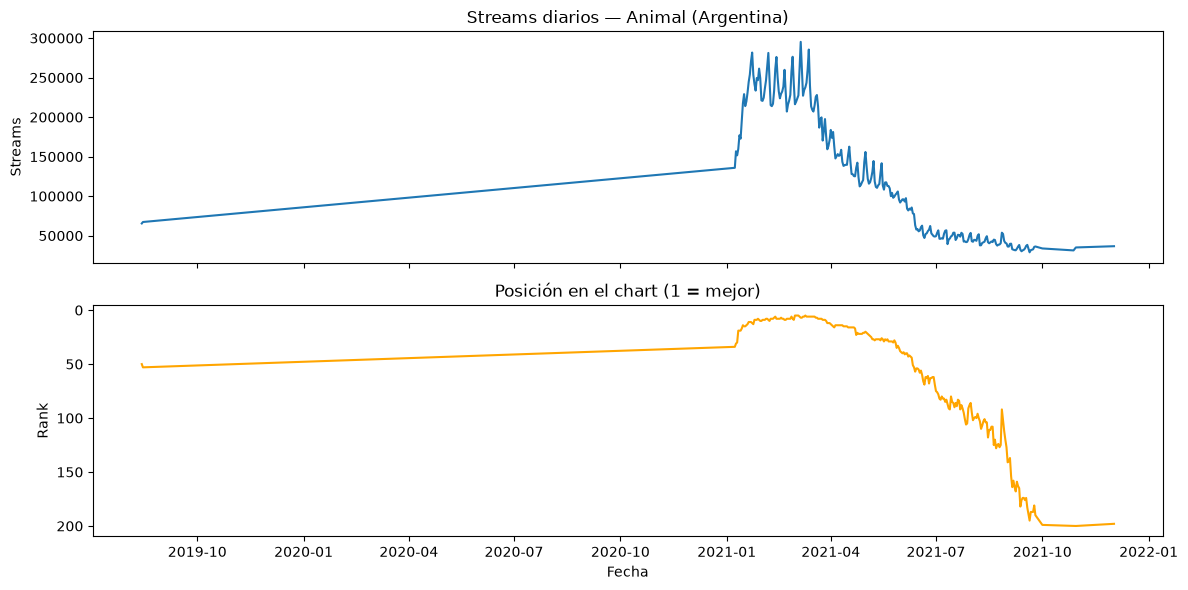

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(serie["date"], serie["streams"])
axes[0].set_title(f"Streams diarios — {CANCION} ({REGION})")
axes[0].set_ylabel("Streams")

axes[1].plot(serie["date"], serie["rank"], color="orange")
axes[1].invert_yaxis()  # rank 1 = mejor puesto, va arriba
axes[1].set_title("Posición en el chart (1 = mejor)")
axes[1].set_ylabel("Rank")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### 1.2 Estadísticos descriptivos (media, desvío, rango, histograma)

Media de streams:  nan
Desvío estándar:   nan
Rango:             nan


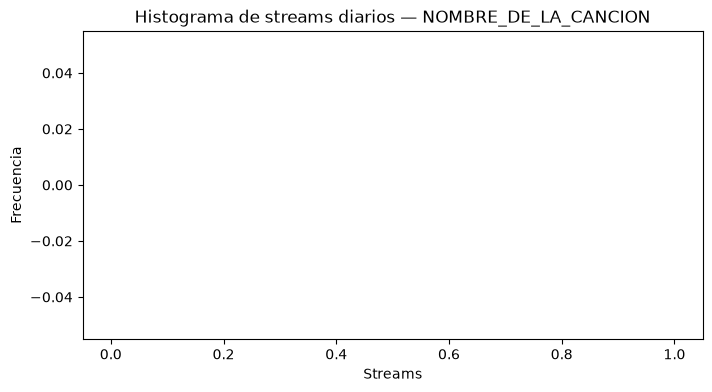

In [7]:
media = serie["streams"].mean()
desvio = serie["streams"].std()
rango = serie["streams"].max() - serie["streams"].min()

print(f"Media de streams:  {media:,.0f}")
print(f"Desvío estándar:   {desvio:,.0f}")
print(f"Rango:             {rango:,.0f}")

plt.figure(figsize=(8, 4))
plt.hist(serie["streams"], bins=30)
plt.title(f"Histograma de streams diarios — {CANCION}")
plt.xlabel("Streams")
plt.ylabel("Frecuencia")
plt.show()

### 1.3 Continuidad de la serie: ¿hay "silencios" (días fuera del chart)?

Si la canción salió y volvió a entrar al Top 200, van a faltar fechas intermedias — el equivalente a un "silencio" en la señal de audio.

In [ ]:
fechas_completas = pd.date_range(serie["date"].min(), serie["date"].max(), freq="D")
faltantes = fechas_completas.difference(serie["date"])

print(f"Días totales del período: {len(fechas_completas)}")
print(f"Días efectivamente en el chart: {len(serie)}")
print(f"Días 'silencio' (fuera del chart): {len(faltantes)}")

### 1.4 Cambios bruscos (saltos día a día)

Diferencia entre muestras consecutivas — picos grandes acá suelen ser un salto viral, una mención en redes, o un cambio de temporada (ej. Navidad).

In [ ]:
serie["diferencia_diaria"] = serie["streams"].diff()

plt.figure(figsize=(12, 4))
plt.plot(serie["date"], serie["diferencia_diaria"])
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Cambio de streams día a día (detección de saltos/cambios bruscos)")
plt.xlabel("Fecha")
plt.ylabel("Δ streams")
plt.show()

top_saltos = serie.reindex(serie["diferencia_diaria"].abs().sort_values(ascending=False).index).head(5)
top_saltos[["date", "streams", "diferencia_diaria"]]

---
## A. Ciclo de vida de un hit: viral vs. catálogo

Estos dos análisis (A y B) usan `data/charts_ar_global.csv` completo (Argentina **y** Global), a diferencia de la sección 1 de arriba que cada integrante corre sobre su propia serie con el `df` de solo Argentina. Por eso cargamos acá un DataFrame aparte (`df_ag`) para no pisar el `df` que usa el resto del notebook.

**Idea:** comparar la "forma de onda" de un hit viral (entra fuerte, pega un pico rápido, decae) contra la de un tema de catálogo (permanece mucho tiempo, sin pico marcado, casi una meseta).</cell id="cell-21">


In [ ]:
df_ag = pd.read_csv("../data/charts_ar_global.csv", parse_dates=["date"])
df_ag = df_ag.sort_values("date")

print("Regiones:", df_ag["region"].unique())
print("Filas:", df_ag.shape[0])

In [ ]:
# --- Candidatos elegidos sobre Top 200 Argentina (ciclo de vida completo, no cortado por el final del dataset) ---

# HIT VIRAL: sesión de Bizarrap con C.R.O. Entra fuerte (salto de streams al día siguiente
# del estreno), pega un pico a los pocos días y decae de forma sostenida durante ~6 meses.
CANCION_HIT = "C.R.O: Bzrp Music Sessions, Vol. 29"
ARTISTA_HIT = "Bizarrap, C.R.O"

# CATÁLOGO: tema de rock nacional que se mantiene casi 4 años en el Top 200 con streams
# estables (sin pico marcado), típico de un tema "de fondo" que no depende de un lanzamiento puntual.
CANCION_CAT = "Pasos Al Costado"
ARTISTA_CAT = "Turf"

top200_ar = df_ag[(df_ag["region"] == "Argentina") & (df_ag["chart"] == "top200")]

serie_hit = top200_ar[
    (top200_ar["title"] == CANCION_HIT) & (top200_ar["artist"] == ARTISTA_HIT)
].sort_values("date").reset_index(drop=True)

serie_cat = top200_ar[
    (top200_ar["title"] == CANCION_CAT) & (top200_ar["artist"] == ARTISTA_CAT)
].sort_values("date").reset_index(drop=True)

print(f"{CANCION_HIT} — {len(serie_hit)} días en el chart ({serie_hit['date'].min().date()} a {serie_hit['date'].max().date()})")
print(f"{CANCION_CAT} — {len(serie_cat)} días en el chart ({serie_cat['date'].min().date()} a {serie_cat['date'].max().date()})")

In [ ]:
def metricas_ciclo_de_vida(serie):
    """Métricas de ciclo de vida (pico, duración, pendientes, área) a partir de
    una serie ordenada por fecha con columnas 'date' y 'streams'."""
    idx_pico = serie["streams"].idxmax()
    dia_pico = serie.loc[idx_pico, "date"]
    streams_pico = serie.loc[idx_pico, "streams"]

    dia_inicio, streams_inicio = serie["date"].iloc[0], serie["streams"].iloc[0]
    dia_fin, streams_fin = serie["date"].iloc[-1], serie["streams"].iloc[-1]

    dias_subida = max((dia_pico - dia_inicio).days, 1)
    dias_bajada = max((dia_fin - dia_pico).days, 1)

    # Días relativos desde la entrada al chart (maneja los "silencios"/huecos del chart)
    dias_relativos = (serie["date"] - dia_inicio).dt.days.to_numpy()

    # np.trapezoid reemplaza a np.trapz (deprecado desde NumPy 2.0); usamos el que exista.
    integral = getattr(np, "trapezoid", None) or np.trapz

    return {
        "dia_pico": dia_pico.date(),
        "streams_pico": streams_pico,
        "duracion_dias": len(serie),
        "pendiente_subida": (streams_pico - streams_inicio) / dias_subida,
        "pendiente_bajada": (streams_fin - streams_pico) / dias_bajada,
        "area_bajo_curva": integral(serie["streams"], x=dias_relativos),
    }


metricas_hit = metricas_ciclo_de_vida(serie_hit)
metricas_cat = metricas_ciclo_de_vida(serie_cat)

for nombre, m in [(CANCION_HIT, metricas_hit), (CANCION_CAT, metricas_cat)]:
    print(f"\n=== {nombre} ===")
    print(f"Día del pico:            {m['dia_pico']}")
    print(f"Streams en el pico:      {m['streams_pico']:,.0f}")
    print(f"Duración en el chart:    {m['duracion_dias']} días")
    print(f"Pendiente de subida:     {m['pendiente_subida']:,.0f} streams/día")
    print(f"Pendiente de caída:      {m['pendiente_bajada']:,.0f} streams/día")
    print(f"Área bajo la curva:      {m['area_bajo_curva']:,.0f} streams·día (energía del ciclo de vida)")

In [ ]:
# Ciclo de vida del hit viral, con las tres fases marcadas: subida, pico, caída
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(serie_hit["date"], serie_hit["streams"], color="crimson", marker="o", markersize=2)

dia_inicio_hit = serie_hit["date"].iloc[0]
dia_fin_hit = serie_hit["date"].iloc[-1]
dia_pico_hit = pd.Timestamp(metricas_hit["dia_pico"])

ax.axvspan(dia_inicio_hit, dia_pico_hit, color="green", alpha=0.1, label="Subida")
ax.axvspan(dia_pico_hit, dia_fin_hit, color="orange", alpha=0.1, label="Caída")
ax.axvline(dia_pico_hit, color="black", linestyle="--", linewidth=1)
ax.annotate(
    "PICO",
    xy=(dia_pico_hit, metricas_hit["streams_pico"]),
    xytext=(10, 10),
    textcoords="offset points",
)

ax.set_title(f"Ciclo de vida — {CANCION_HIT} ({ARTISTA_HIT})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Streams diarios")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Comparación de forma: streams vs. "días desde la entrada al chart" (para poder
# superponer un ciclo corto de ~6 meses con uno de casi 4 años en el mismo eje)
dias_rel_hit = (serie_hit["date"] - serie_hit["date"].iloc[0]).dt.days
dias_rel_cat = (serie_cat["date"] - serie_cat["date"].iloc[0]).dt.days

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dias_rel_hit, serie_hit["streams"], color="crimson", label=f"Hit viral — {CANCION_HIT}")
ax.plot(dias_rel_cat, serie_cat["streams"], color="steelblue", label=f"Catálogo — {CANCION_CAT}")

ax.set_title("Ciclo de vida: hit viral vs. catálogo")
ax.set_xlabel("Días desde la entrada al chart")
ax.set_ylabel("Streams diarios")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión A:** el hit viral tiene una "forma de onda" con transitorio marcado: el 90% del ascenso pasa en los primeros 3-4 días (pendiente de subida muy pronunciada) y después decae de forma sostenida durante meses hasta salir del chart — es una señal claramente no estacionaria, dominada por el evento de lanzamiento. El tema de catálogo, en cambio, es casi una meseta: entra sin salto brusco, se mantiene en una banda angosta de streams durante años (pendientes de subida y bajada mucho más chicas en valor absoluto) y no tiene un pico dominante — se parece más a una señal estacionaria de bajo nivel de "ruido" que a un transitorio. El área bajo la curva del catálogo termina siendo mayor en el largo plazo (mucho más tiempo acumulando streams moderados) aunque su pico nunca se acerque al del hit.

---
## B. Comparación Argentina vs Global (superposición de artistas)

**Idea:** construir una serie temporal nueva —"cantidad de artistas en común entre el Top 200 de Argentina y el Top 200 Global, por día"— para ver si el consumo argentino tiene un componente propio o sigue de cerca las tendencias globales, y con qué desfasaje.

In [ ]:
# Un mismo título suele acreditar varios artistas en un solo string (ej. "Bad Bunny, Ozuna").
# Separamos artista por artista para comparar entidades individuales, no strings de crédito completos.
top200 = df_ag[df_ag["chart"] == "top200"].copy()
top200["artistas_individuales"] = top200["artist"].str.split(", ")
exploded = top200.explode("artistas_individuales")

artistas_ar_por_dia = exploded[exploded["region"] == "Argentina"].groupby("date")["artistas_individuales"].apply(set)
artistas_global_por_dia = exploded[exploded["region"] == "Global"].groupby("date")["artistas_individuales"].apply(set)

fechas_comunes = artistas_ar_por_dia.index.intersection(artistas_global_por_dia.index)
artistas_en_comun = pd.Series(
    {fecha: len(artistas_ar_por_dia[fecha] & artistas_global_por_dia[fecha]) for fecha in fechas_comunes},
    name="artistas_en_comun",
).sort_index()

artistas_en_comun_semanal = artistas_en_comun.resample("W").mean()

print(artistas_en_comun.describe())

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(artistas_en_comun.index, artistas_en_comun.values, color="lightgray", linewidth=0.8, label="Diaria")
ax.plot(artistas_en_comun_semanal.index, artistas_en_comun_semanal.values, color="darkblue", linewidth=1.5, label="Promedio semanal")

ax.set_title("Cantidad de artistas en común — Top 200 Argentina ∩ Top 200 Global")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de artistas en común")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

picos_idx, _ = find_peaks(
    artistas_en_comun_semanal.values,
    distance=3,
    prominence=artistas_en_comun_semanal.std(),
)
picos_semanales = artistas_en_comun_semanal.iloc[picos_idx].sort_values(ascending=False)

print("=== Semanas con mayor superposición Argentina-Global ===")
print(picos_semanales.head(5))

# Para el pico más importante, buscamos el día exacto (dentro de esa semana) con más
# artistas en común, y qué artistas explican esa superposición.
semana_pico = picos_semanales.index[0]
ventana = artistas_en_comun[
    (artistas_en_comun.index > semana_pico - pd.Timedelta(days=6)) & (artistas_en_comun.index <= semana_pico)
]
dia_pico_b = ventana.idxmax()
artistas_explican = artistas_ar_por_dia[dia_pico_b] & artistas_global_por_dia[dia_pico_b]

print(f"\nDía con más superposición en esa semana: {dia_pico_b.date()} ({ventana.max()} artistas en común)")
print(f"Algunos de los artistas que explican el pico: {sorted(artistas_explican)[:15]}")

# Canciones de esos artistas que estaban en el Top 200 Argentina justo ese día.
# Usamos el DataFrame explotado (una fila por artista individual), no `top200`
# directo, porque ahí "artistas_individuales" es una lista y .isin() nunca matchea.
canciones_ese_dia = exploded[
    (exploded["region"] == "Argentina")
    & (exploded["date"] == dia_pico_b)
    & (exploded["artistas_individuales"].isin(artistas_explican))
][["title", "artist", "rank"]].drop_duplicates().sort_values("rank")

print("\nCanciones de esos artistas en el Top 200 Argentina ese día:")
print(canciones_ese_dia.head(15).to_string(index=False))

In [ ]:
# Adicional: ¿con cuántos días de desfasaje sigue Argentina las entradas nuevas al chart Global?
# Construimos dos series diarias ("cantidad de entradas nuevas -NEW_ENTRY- al Top 200 ese día")
# y las cruzamos con la función compartida de correlación cruzada de src/.
import sys
sys.path.append("..")
from src.correlation import correlacion_cruzada

entradas_global = top200[(top200["region"] == "Global") & (top200["trend"] == "NEW_ENTRY")].groupby("date").size()
entradas_ar = top200[(top200["region"] == "Argentina") & (top200["trend"] == "NEW_ENTRY")].groupby("date").size()

rango_fechas = pd.date_range(df_ag["date"].min(), df_ag["date"].max(), freq="D")
entradas_global = entradas_global.reindex(rango_fechas, fill_value=0)
entradas_ar = entradas_ar.reindex(rango_fechas, fill_value=0)

cc = correlacion_cruzada(entradas_global.values, entradas_ar.values, max_lag=30)

plt.figure(figsize=(10, 4))
plt.stem(cc.index, cc.values)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación cruzada: entradas nuevas Global vs. Argentina\n(lag > 0: Global adelanta a Argentina)")
plt.xlabel("Lag (días)")
plt.ylabel("Correlación normalizada")
plt.tight_layout()
plt.show()

lag_maximo = cc.idxmax()
print(f"Lag con mayor correlación: {lag_maximo} días (correlación = {cc.max():.3f})")
print("\nTop 5 lags por correlación:")
print(cc.sort_values(ascending=False).head(5))

**Conclusión B:** la correlación cruzada tiene su máximo en lag 0, es decir que el grueso de las entradas nuevas al chart argentino ocurre el mismo día que las entradas al chart Global — Argentina no le va muy a la zaga a las tendencias globales, al menos no en términos de qué día "aparece" una canción. Se ve además una correlación secundaria elevada en lags múltiplos de 7 (7, 14, 21, 28), que no es tanto un desfasaje real sino el reflejo de que los lanzamientos discográficos ocurren mayormente los viernes en todo el mundo — genera una periodicidad semanal en ambas series de entradas que la correlación cruzada capta como picos cada 7 días. En cuanto a la superposición de artistas, el pico histórico (mediados de 2017) coincide con una ventana en la que gran parte del Top 200 argentino estaba copado por los mismos hits de pop/reggaetón que dominaban el ranking Global (Ed Sheeran, Shakira, Maluma, Justin Bieber, etc.) — evidencia de que, más que un consumo "propio", buena parte del chart argentino de esos años estaba alineado con el fenómeno del crossover latino a nivel mundial.

---
## 2. Dominio tiempo-frecuencia (Fourier)
*(pendiente — acá va la FFT de la serie, buscar periodicidad semanal, y si eligieron una canción navideña, la componente anual)*

## 3. Filtrado
*(pendiente — medias móviles MA7 / MA21 para separar componente semanal y tendencia, filtro pasa-banda alrededor de 1/7 días)*

## 4. Energía de la señal
*(pendiente)*

## 5. Comparación / correlación entre series del equipo
*(pendiente — acá se juntan las 4 series del grupo)*

## 6. Estacionariedad y forecasting (ARIMA / Prophet)
*(pendiente)*

## 7. Conclusiones
*(pendiente)*